In [82]:
IMAGE_DIR = "zebra.jpg"

## Load Image

In [83]:
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np

In [84]:
image = cv.imread(IMAGE_DIR)
img_h, img_w, img_c = image.shape
image.shape

(391, 586, 3)

(np.float64(-0.5), np.float64(585.5), np.float64(390.5), np.float64(-0.5))

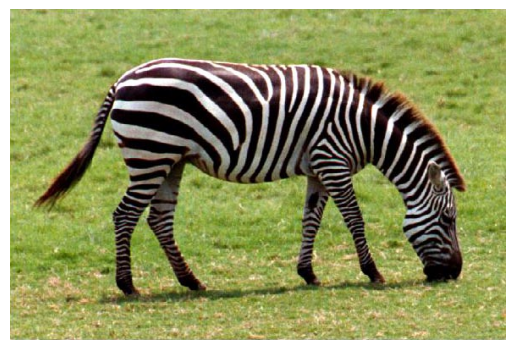

In [85]:
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.axis("off")

In [86]:
image_data = image.reshape((-1, 3))
image_data.shape

(229126, 3)

## Gaussian Mixture Model

In [87]:
from sklearn.mixture import GaussianMixture

In [88]:
gmm= GaussianMixture(n_components=2, covariance_type='full', random_state=0)

In [89]:
gmm.fit(image_data)

,n_components,2
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


In [90]:
labels = gmm.predict(image_data)

In [91]:
labels.shape

(229126,)

In [92]:
labels = labels.reshape((img_h, img_w, 1))

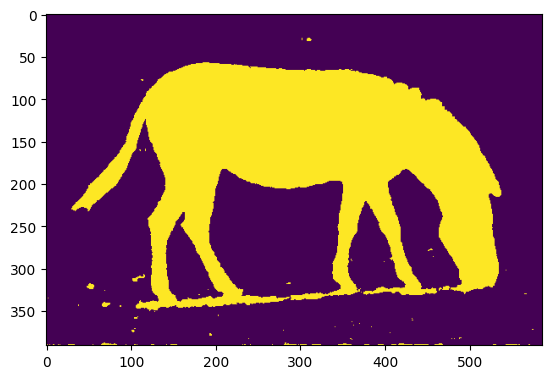

In [93]:
plt.imshow(labels)

## Segment the image

In [94]:
segmented_image = np.zeros_like(image)
segmented_image = np.where(labels==0, 225, image).astype(np.uint8)

(np.float64(-0.5), np.float64(585.5), np.float64(390.5), np.float64(-0.5))

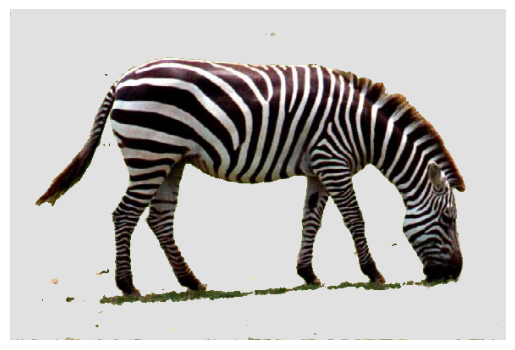

In [95]:
plt.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(585.5), np.float64(390.5), np.float64(-0.5))

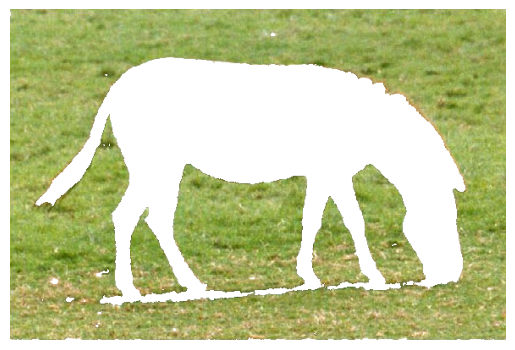

In [96]:
segmented_image = np.where(labels == 1, 255, image).astype(np.uint8)
plt.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))
plt.axis("off")
